## 1. Perkenalan Dataset

Dataset yang digunakan pada proyek ini adalah **Loan Prediction Dataset**, yang diperoleh dari Kaggle:

📎 https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

### Deskripsi Masalah
Proyek ini bertujuan untuk membangun model klasifikasi guna memprediksi apakah aplikasi pinjaman dari calon peminjam akan disetujui atau tidak, berdasarkan informasi pribadi dan keuangan mereka.

### Deskripsi Fitur
Berikut beberapa kolom penting yang tersedia dalam dataset:

- `Loan_ID` : ID unik peminjam  
- `Gender` : Jenis kelamin  
- `Married` : Status pernikahan  
- `Dependents` : Jumlah tanggungan  
- `Education` : Lulusan atau tidak  
- `Self_Employed` : Wirausaha atau bukan  
- `ApplicantIncome` : Pendapatan utama peminjam  
- `CoapplicantIncome` : Pendapatan tambahan (jika ada)  
- `LoanAmount` : Jumlah pinjaman yang diminta  
- `Loan_Amount_Term` : Lama pinjaman (bulan)  
- `Credit_History` : Riwayat kredit  
- `Property_Area` : Tipe lokasi properti  
- `Loan_Status` : Target (Y/N) → apakah pinjaman disetujui


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Library berhasil diimpor.")

Library berhasil diimpor.


# **3. Memuat Dataset**

In [20]:
df = pd.read_csv("../loan_prediction_raw/train.csv")

# tampilkan 5 baris pertama
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [21]:
# cek dimensi data
print("Jumlah baris dan kolom:", df.shape)

# info tipe data
df.info()

# statistik deskriptif
df.describe()

Jumlah baris dan kolom: (614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [22]:
# 4.1. Cek jumlah missing values per kolom
missing = df.isnull().sum()
print("Jumlah nilai kosong per kolom:\n", missing[missing > 0])

Jumlah nilai kosong per kolom:
 Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


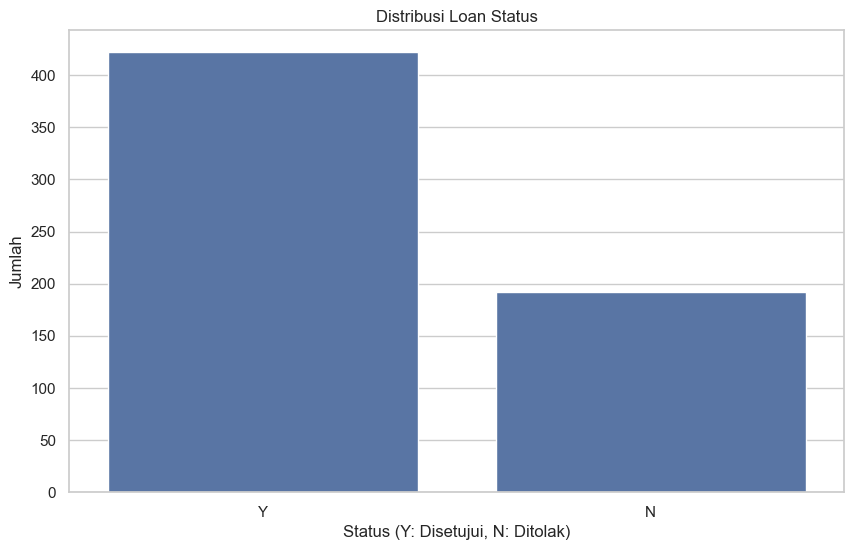

Proporsi:
 Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [23]:
# 4.2. Distribusi Target Loan_Status
sns.countplot(data=df, x='Loan_Status')
plt.title('Distribusi Loan Status')
plt.xlabel('Status (Y: Disetujui, N: Ditolak)')
plt.ylabel('Jumlah')
plt.show()

# Proporsi
loan_counts = df['Loan_Status'].value_counts(normalize=True) * 100
print("Proporsi:\n", loan_counts)

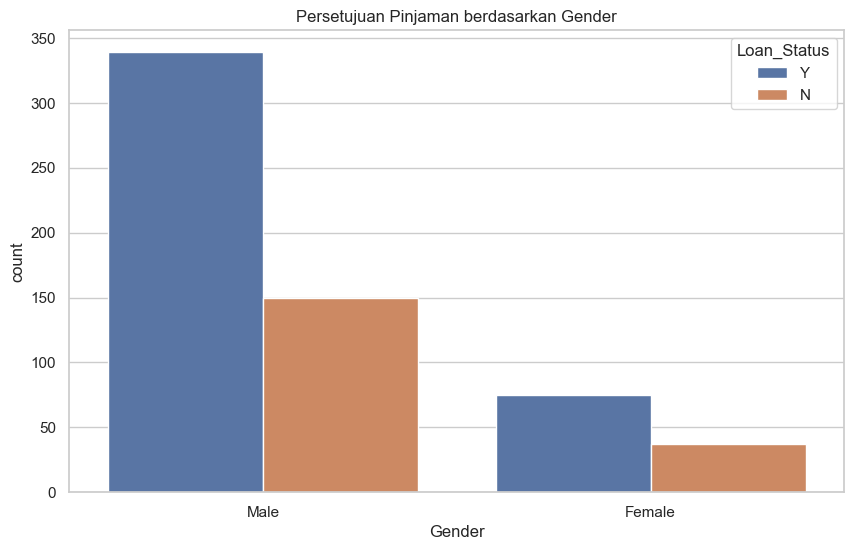

In [24]:
# 4.3 Analisis Kategorikal terhadap Target

# 4.3.1 Gender vs Loan_Status
sns.countplot(data=df, x='Gender', hue='Loan_Status')
plt.title('Persetujuan Pinjaman berdasarkan Gender')
plt.show()

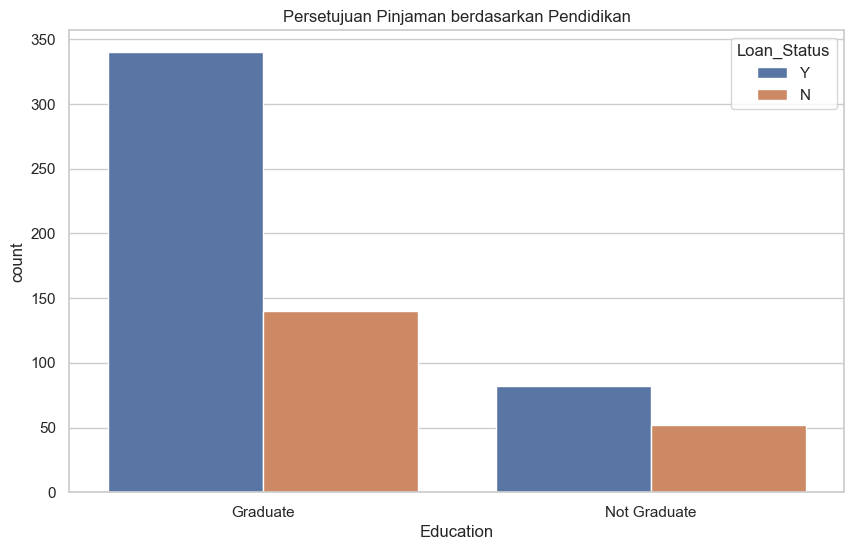

In [25]:
# 4.3.2 Education vs Loan_Status
sns.countplot(data=df, x='Education', hue='Loan_Status')
plt.title('Persetujuan Pinjaman berdasarkan Pendidikan')
plt.show()

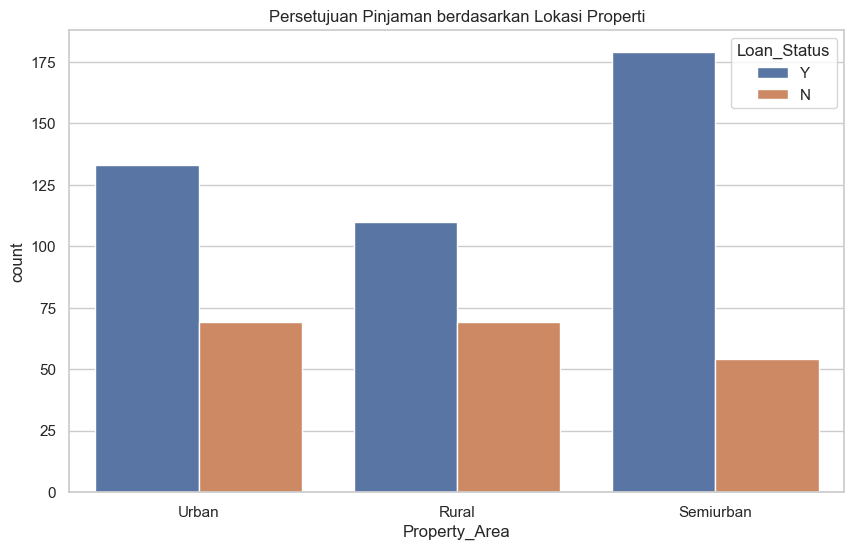

In [26]:
# 4.3.3 Property Area vs Loan_Status
sns.countplot(data=df, x='Property_Area', hue='Loan_Status')
plt.title('Persetujuan Pinjaman berdasarkan Lokasi Properti')
plt.show()

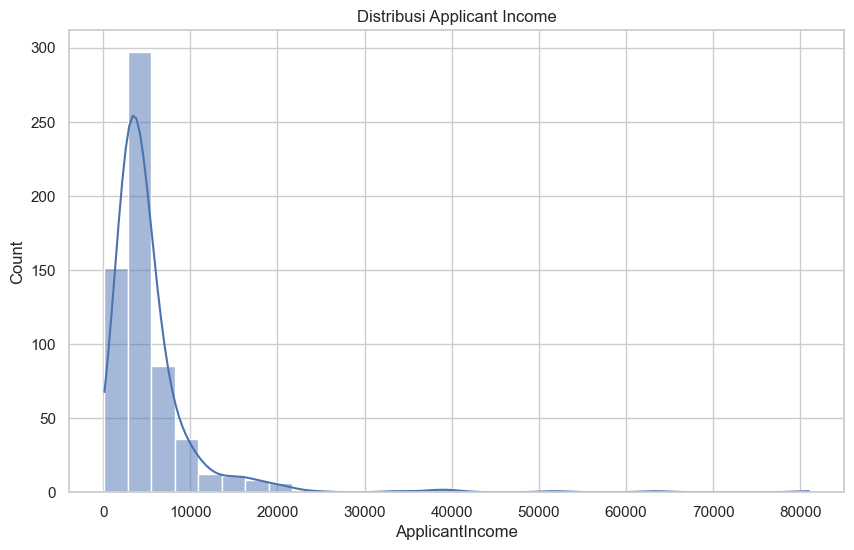

In [27]:
# 4.4 Distribusi Fitur Numerik

# 4.4.1 ApplicantIncome
sns.histplot(df['ApplicantIncome'], kde=True, bins=30)
plt.title('Distribusi Applicant Income')
plt.show()

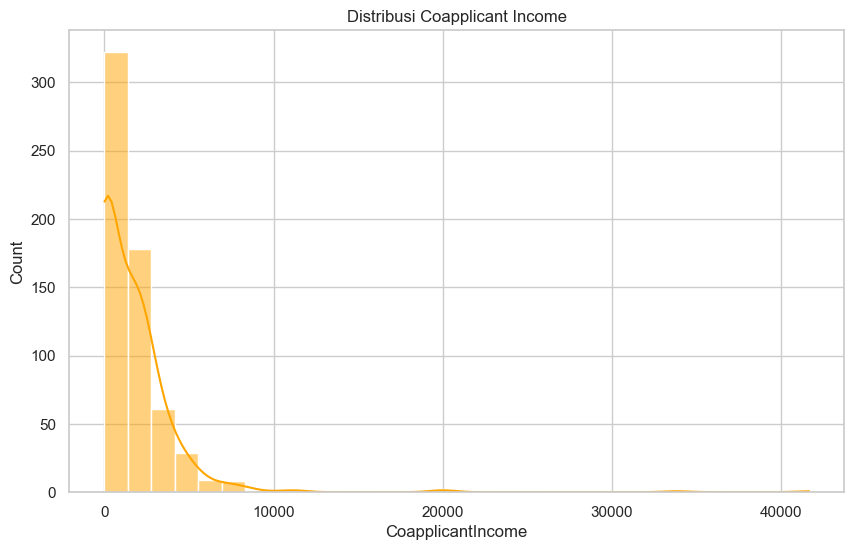

In [28]:
# 4.4.2 CoapplicantIncome
sns.histplot(df['CoapplicantIncome'], kde=True, bins=30, color='orange')
plt.title('Distribusi Coapplicant Income')
plt.show()

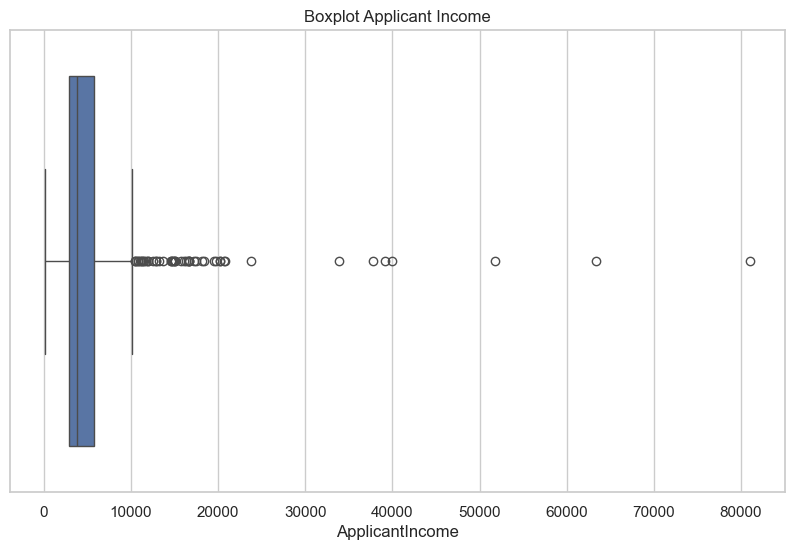

In [29]:
# 4.5 Deteksi Outlier via Boxplot

# ApplicantIncome
sns.boxplot(x=df['ApplicantIncome'])
plt.title("Boxplot Applicant Income")
plt.show()

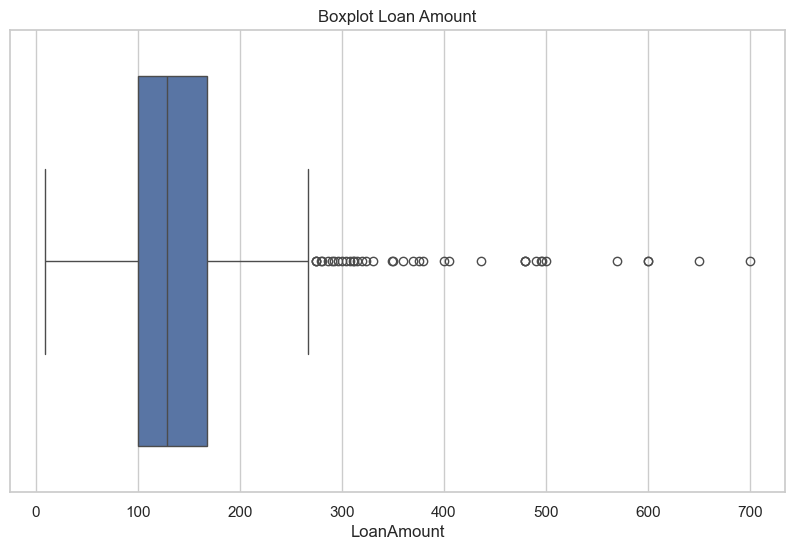

In [30]:
# LoanAmount
sns.boxplot(x=df['LoanAmount'])
plt.title("Boxplot Loan Amount")
plt.show()


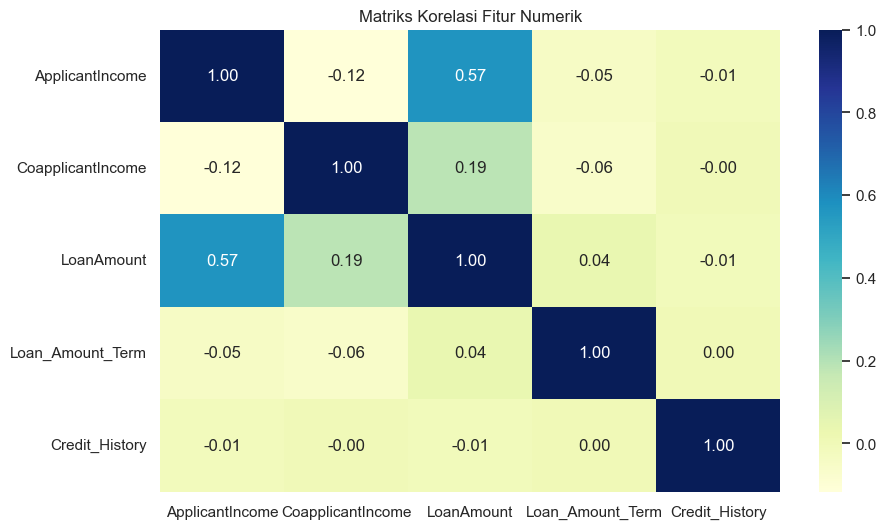

In [31]:
# 4.6 Korelasi Antar Variabel Numerik
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

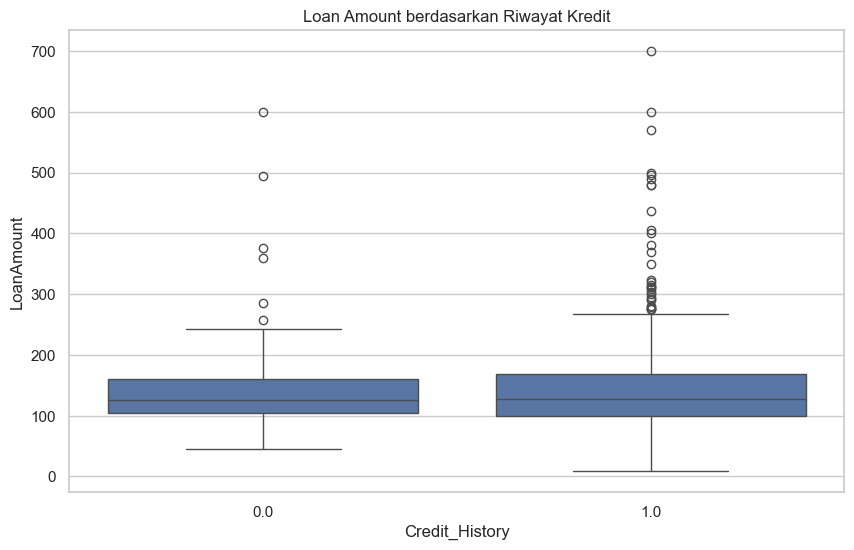

In [32]:
# 4.7 LoanAmount berdasarkan Credit History
sns.boxplot(x='Credit_History', y='LoanAmount', data=df)
plt.title('Loan Amount berdasarkan Riwayat Kredit')
plt.show()

In [33]:
# 4.8 Cross-tab Credit History vs Loan Status
pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index') * 100

Loan_Status,N,Y
Credit_History,,
0.0,92.134831,7.865169
1.0,20.421053,79.578947


## Insight :
- Credit_History sangat menentukan disetujui atau tidak (akan sangat penting untuk model)

- Outlier signifikan pada ApplicantIncome dan LoanAmount, penting untuk ditangani sebelum modeling

- Kolom Dependents memiliki nilai '3+' yang perlu disesuaikan menjadi angka (misalnya 3)

- Target (Loan_Status) imbalance → akan dipertimbangkan pada modeling

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [34]:
# 5.1 Drop kolom tidak relevan
df.drop('Loan_ID', axis=1, inplace=True)

# 5.2 Ubah '3+' di Dependents → 3
df['Dependents'] = df['Dependents'].replace('3+', '3')

# 5.3 Imputasi missing values
# Kategorikal → modus
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerik
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# 5.4 Encoding kategorikal
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']:
    df[col] = le.fit_transform(df[col])


# 5.5 Ubah Dependents ke integer
df['Dependents'] = df['Dependents'].astype(int)

In [35]:
# 5.6 Simpan data hasil preprocessing ke folder yang diminta

# buat folder jika belum ada (khusus jika jalankan ulang kernel)
import os
output_path = "../preprocessing/loan_prediction_preprocessing/"
os.makedirs(output_path, exist_ok=True)

# simpan ke CSV
df.to_csv(output_path + "loan_cleaned.csv", index=False)

print("Dataset bersih berhasil disimpan di:", output_path + "loan_cleaned.csv")

Dataset bersih berhasil disimpan di: ../preprocessing/loan_prediction_preprocessing/loan_cleaned.csv
